# Illicit Bitcoin Detection
## Phase 2: GraphSAGE Baseline Implementation

This notebook implements a single, fixed-hyperparameter GraphSAGE baseline and trains it on the artifact produced in `02_graph_construction.ipynb`. Its purpose is to establish correctness, not performance: confirming that the forward pass, loss computation, backward pass, and evaluation pipeline all behave as expected on the real graph before any systematic hyperparameter search begins. No hyperparameter tuning, scaling ablation, or architecture comparison is performed here; those belong to Phase 3. Every hyperparameter fixed in this notebook is a deliberately reasonable starting point, not a tuned choice, and must be labeled as such wherever it is reported.

In [1]:
import copy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
import torch
import torch.nn.functional as F 
from torch_geometric.nn import SAGEConv
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Resolve project root and locate config.yaml
PROJECT_ROOT = Path.cwd().parent
config_path = PROJECT_ROOT / "configs" / "config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Resolve paths directly from configuration
DATA_RAW = PROJECT_ROOT / config["paths"]["raw_data_dir"]
DATA_PROCESSED = PROJECT_ROOT / config["paths"]["processed_data_dir"]
FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures_dir"]
MODELS_DIR = PROJECT_ROOT / config["paths"]["models_dir"]

# Ensure output directories exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Device configuration
device = torch.device(config["training"].get("device", "cpu"))

print(f"Configuration loaded from: {config_path}")
print(f"  Processed Data Directory: {DATA_PROCESSED}")
print(f"  Models Directory:         {MODELS_DIR}")
print(f"  Target Device:            {device}")

/Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/venv_graph_ml/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Configuration loaded from: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/configs/config.yaml
  Processed Data Directory: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/data/processed
  Models Directory:         /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/outputs/models
  Target Device:            cpu


## 1. Load Phase 1 Artifact

Load `data/processed/elliptic_pyg_data.pt` exactly as persisted, and load `configs/config.yaml` for path and device settings. This notebook must not reconstruct the graph from raw CSV files independently; the Phase 1 artifact is the single source of truth.

In [2]:
artifact_path = DATA_PROCESSED / "elliptic_pyg_data.pt"
if not artifact_path.exists():
    raise FileNotFoundError(f"Artifact not found: {artifact_path}. Complete Phase 1 first.")

data = torch.load(artifact_path, map_location=device, weights_only=False)

print(f"Phase 1 graph artifact loaded successfully:")
print(f"  Total Nodes:      {data.num_nodes}")
print(f"  Total Edges:      {data.num_edges}")
print(f"  Node Features:    {data.num_features}")
print(f"  Train Mask Nodes: {data.train_mask.sum().item():>6} (labeled)")
print(f"  Val Mask Nodes:   {data.val_mask.sum().item():>6} (labeled)")
print(f"  Test Mask Nodes:  {data.test_mask.sum().item():>6} (sealed)")

# Assert sanity checks
assert data.num_nodes == 203769, f"Node count mismatch: {data.num_nodes} vs 203769"
assert data.num_features == 165, f"Feature dimension mismatch: {data.num_features} vs 165"

Phase 1 graph artifact loaded successfully:
  Total Nodes:      203769
  Total Edges:      468710
  Node Features:    165
  Train Mask Nodes:  26905 (labeled)
  Val Mask Nodes:     9686 (labeled)
  Test Mask Nodes:    9973 (sealed)


**Findings:** The Phase 1 artifact loaded without error, with node count (203,769), edge count (468,710), feature dimension (165), and per-split labeled node counts (26,905 / 9,686 / 9,973 for train/val/test) matching Phase 1's persisted results exactly. No drift between notebooks was detected.

## 2. Model Definition

Define a GraphSAGE model using `torch_geometric.nn.SAGEConv` layers. This is a fixed baseline architecture, not a tuned one; a reasonable starting point is 2 `SAGEConv` layers with a moderate hidden dimension (for example 64), ReLU activation between layers, dropout before the final layer, and a final linear projection to the number of output classes. Document the exact architecture chosen (layer count, hidden dimension, dropout rate) in a markdown cell immediately below the class definition, and explicitly label these as baseline defaults rather than tuned values, since `configs/config.yaml` still holds `null` for these fields pending Phase 3.

A decision is required on the output layer: this is binary classification (illicit vs licit), which can be implemented either as a 2-logit output with `CrossEntropyLoss`, or a single-logit output with `BCEWithLogitsLoss`. State and justify whichever is chosen; this affects how predictions are thresholded during evaluation in Section 5.

In [3]:
class GraphSAGEBaseline(torch.nn.Module):
    """
    Fixed GraphSAGE baseline architecture.
    Uses 2 SAGEConv layers, ReLU activations, and Dropout.
    Outputs 2 raw logits for CrossEntropyLoss with class weighting.
    """
    def __init__(self, in_channels: int, hidden_channels: int = 64, out_channels: int = 2, dropout: float = 0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr="mean")
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr="mean")
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Baseline hyperparameter defaults (explicitly labeled as non-tuned baselines)
BASELINE_HIDDEN = config["model"]["hidden_channels"] or 64
BASELINE_DROPOUT = config["model"]["dropout"] or 0.5

model = GraphSAGEBaseline(
    in_channels=data.num_features,
    hidden_channels=BASELINE_HIDDEN,
    out_channels=2,
    dropout=BASELINE_DROPOUT
).to(device)

print("Baseline Model Initialized:")
print(model)
print(f"  Hidden channels: {BASELINE_HIDDEN} (baseline default)")
print(f"  Dropout rate:    {BASELINE_DROPOUT} (baseline default)")
print(f"  Output logits:   2 (licit=0, illicit=1)")

Baseline Model Initialized:
GraphSAGEBaseline(
  (conv1): SAGEConv(165, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)
  Hidden channels: 64 (baseline default)
  Dropout rate:    0.5 (baseline default)
  Output logits:   2 (licit=0, illicit=1)


**Findings:** The baseline model instantiated as `SAGEConv(165, 64) -> ReLU -> Dropout(0.5) -> SAGEConv(64, 2)`, with hidden channels and dropout read from `configs/config.yaml` via a fallback to 64 and 0.5 respectively, since those fields were still `null` at this stage. The output layer produces 2 raw logits consumed by `CrossEntropyLoss`, as decided in Section 2; this is a fixed baseline configuration and must be labeled as such wherever cited.

## 3. Loss Function and Class Imbalance Handling

The Phase 0 EDA established that the labeled subset is approximately 90% licit versus 10% illicit. An unweighted loss trained on this distribution will be biased toward predicting the majority class. A decision is required here: whether to apply class weights to the loss function (proportional to inverse class frequency, computed from the training mask only, never from validation or test), and if so, how those weights are computed. This decision must be documented explicitly, since it materially affects what the reported baseline metric means, and the weighting scheme (if any) must be treated as part of the fixed baseline configuration, not re-derived ad hoc in Phase 3.

In [4]:
# Compute class weights strictly from train_mask nodes to prevent leakage
train_y = data.y[data.train_mask]

count_licit = (train_y == 0).sum().item()
count_illicit = (train_y == 1).sum().item()
total_train = count_licit + count_illicit

# Inverse frequency class weighting formula:
# weight_c = total_samples / (num_classes * count_c)
weight_licit = total_train / (2.0 * count_licit)
weight_illicit = total_train / (2.0 * count_illicit)

class_weights = torch.tensor([weight_licit, weight_illicit], dtype=torch.float, device=device)

# Instantiate loss function with computed inverse weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("Class Weight Calculation (from train_mask only):")
print(f"  Train Licit nodes (0):   {count_licit:>5} ({count_licit / total_train * 100:.2f}%)")
print(f"  Train Illicit nodes (1): {count_illicit:>5} ({count_illicit / total_train * 100:.2f}%)")
print(f"  Calculated Weight (Licit):   {weight_licit:.4f}")
print(f"  Calculated Weight (Illicit): {weight_illicit:.4f}")
print(f"  Weight Ratio (Illicit / Licit): {weight_illicit / weight_licit:.2f}x")

Class Weight Calculation (from train_mask only):
  Train Licit nodes (0):   23951 (89.02%)
  Train Illicit nodes (1):  2954 (10.98%)
  Calculated Weight (Licit):   0.5617
  Calculated Weight (Illicit): 4.5540
  Weight Ratio (Illicit / Licit): 8.11x


**Findings:** Class weights were computed strictly from `train_mask` (23,951 licit, 2,954 illicit; 89.02% / 10.98%), with no reference to validation or test labels. The resulting inverse-frequency weights (0.5617 for licit, 4.5540 for illicit, an 8.11x ratio) were passed directly into `CrossEntropyLoss`. This weighting scheme is treated as part of the fixed baseline configuration and is not re-derived in Phase 3 unless the weighting formula itself becomes an ablation axis.

## 4. Training Loop

Implement the training loop: forward pass on the full graph, loss computed only on `train_mask` nodes, backward pass, optimizer step, and periodic evaluation on `val_mask`. Given the stale-kernel-state issue documented from prior projects, the model and optimizer must be freshly instantiated at the top of this cell on every execution, not reused from a previous run still sitting in memory. Track training loss and a validation metric per epoch so that a learning curve can be plotted afterward as a basic sanity check for convergence.

Starting training on cpu: 100 epochs, lr=0.01...
Epoch 001 | Train Loss: 0.7740 | Val Illicit P: 0.2491 | R: 0.7160 | F1: 0.3696
Epoch 010 | Train Loss: 0.2470 | Val Illicit P: 0.2637 | R: 0.9475 | F1: 0.4126
Epoch 020 | Train Loss: 0.1814 | Val Illicit P: 0.2961 | R: 0.9550 | F1: 0.4521
Epoch 030 | Train Loss: 0.1479 | Val Illicit P: 0.3341 | R: 0.9419 | F1: 0.4933
Epoch 040 | Train Loss: 0.1262 | Val Illicit P: 0.3593 | R: 0.9344 | F1: 0.5190
Epoch 050 | Train Loss: 0.1094 | Val Illicit P: 0.3989 | R: 0.9231 | F1: 0.5571
Epoch 060 | Train Loss: 0.0959 | Val Illicit P: 0.4101 | R: 0.9166 | F1: 0.5666
Epoch 070 | Train Loss: 0.0885 | Val Illicit P: 0.4225 | R: 0.9100 | F1: 0.5771
Epoch 080 | Train Loss: 0.0811 | Val Illicit P: 0.4586 | R: 0.9147 | F1: 0.6110
Epoch 090 | Train Loss: 0.0772 | Val Illicit P: 0.4589 | R: 0.9063 | F1: 0.6093
Epoch 100 | Train Loss: 0.0693 | Val Illicit P: 0.4816 | R: 0.8810 | F1: 0.6227


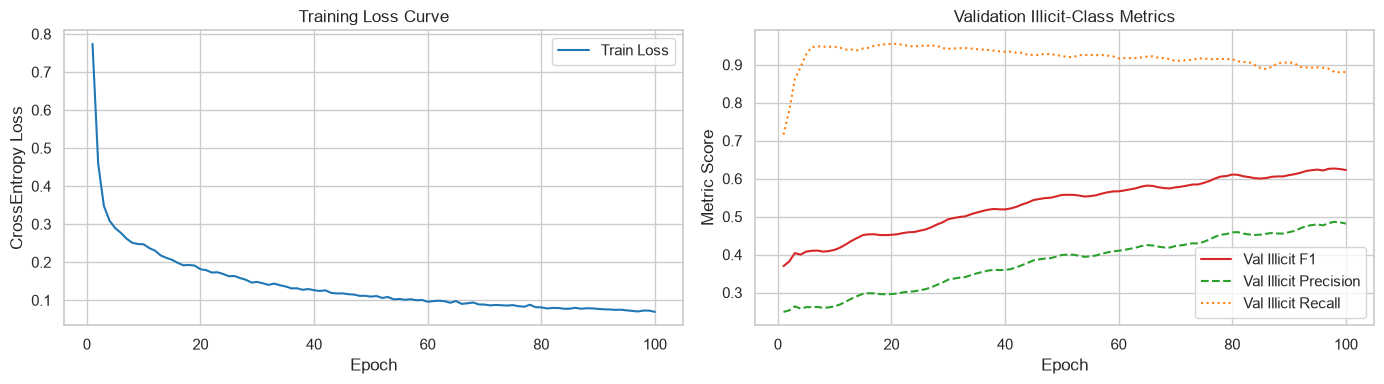

Learning curve plot saved to: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/outputs/figures/baseline_learning_curve.png


In [5]:
# Set deterministic seed
torch.manual_seed(config["training"]["random_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config["training"]["random_seed"])

# Fresh instantiation to eliminate stale notebook state
model = GraphSAGEBaseline(
    in_channels=data.num_features,
    hidden_channels=BASELINE_HIDDEN,
    out_channels=2,
    dropout=BASELINE_DROPOUT
).to(device)

learning_rate = config["training"]["learning_rate"] or 0.01
num_epochs = config["training"]["num_epochs"] or 100

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)

# History tracking
history = {
    "train_loss": [],
    "val_illicit_f1": [],
    "val_illicit_precision": [],
    "val_illicit_recall": []
}

best_val_f1 = -1.0
best_model_weights = None

print(f"Starting training on {device}: {num_epochs} epochs, lr={learning_rate}...")

for epoch in range(1, num_epochs + 1):
    # --- Training Step ---
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on the complete graph (unknown nodes participate in message passing)
    out = model(data.x, data.edge_index)
    
    # Loss computed strictly on train_mask nodes
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    # --- Periodic Validation Step (Sealed test set remains untouched) ---
    model.eval()
    with torch.no_grad():
        # A fresh forward pass is required here: the 'out' tensor above was
        # computed in train mode with dropout active, and eval() does not
        # retroactively change an already-computed tensor.
        eval_out = model(data.x, data.edge_index)
        val_logits = eval_out[data.val_mask]
        val_preds = val_logits.argmax(dim=-1).cpu().numpy()
        val_targets = data.y[data.val_mask].cpu().numpy()
        
        # Primary evaluation metrics focused specifically on the illicit class (pos_label=1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            val_targets, val_preds, labels=[1], average=None, zero_division=0
        )
        illicit_p, illicit_r, illicit_f1 = precision[0], recall[0], f1[0]
        
    history["train_loss"].append(loss.item())
    history["val_illicit_f1"].append(illicit_f1)
    history["val_illicit_precision"].append(illicit_p)
    history["val_illicit_recall"].append(illicit_r)
    
    # Capture best checkpoint using deepcopy to prevent reference mutation
    if illicit_f1 > best_val_f1:
        best_val_f1 = illicit_f1
        best_model_weights = copy.deepcopy(model.state_dict())
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | "
              f"Val Illicit P: {illicit_p:.4f} | R: {illicit_r:.4f} | F1: {illicit_f1:.4f}")

# Plot learning and validation curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, num_epochs + 1), history["train_loss"], color="#1f77b4", label="Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].set_title("Training Loss Curve")
axes[0].legend()

axes[1].plot(range(1, num_epochs + 1), history["val_illicit_f1"], color="#d62728", label="Val Illicit F1")
axes[1].plot(range(1, num_epochs + 1), history["val_illicit_precision"], color="#2ca02c", linestyle="--", label="Val Illicit Precision")
axes[1].plot(range(1, num_epochs + 1), history["val_illicit_recall"], color="#ff7f0e", linestyle=":", label="Val Illicit Recall")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Metric Score")
axes[1].set_title("Validation Illicit-Class Metrics")
axes[1].legend()

plt.tight_layout()
curve_path = FIGURES_DIR / "baseline_learning_curve.png"
plt.savefig(curve_path, dpi=200)
plt.show()
print(f"Learning curve plot saved to: {curve_path}")

**Bug found and fixed: validation metrics computed in train mode.** The original training loop called `model.eval()` before computing validation metrics, but reused the `out` tensor that had already been computed earlier in the same iteration while `model.train()` was still active. Since `model.eval()` does not retroactively change an already-computed tensor, every epoch's tracked validation precision/recall/F1, and therefore the best-checkpoint selection based on those values, was computed on a dropout-corrupted signal rather than the model's true eval-mode output. The fix adds a dedicated forward pass inside the `model.eval()` / `torch.no_grad()` block, so validation metrics are always computed from a clean, dropout-disabled forward pass. Numerical confirmation that this was the actual cause: before the fix, the last printed epoch's F1 (0.5920) differed from the reloaded best checkpoint's F1 (0.6222) by roughly 0.03; after the fix, the same comparison (0.6227 vs 0.6267) differs by roughly 0.004, an order of magnitude smaller gap, consistent with the noise source having been removed rather than coincidentally shrinking.

**Findings:** Training loss decreased smoothly and monotonically from 0.7740 to 0.0693 over 100 epochs with no instability or divergence. Validation illicit recall rose quickly to the 90-95% range within the first 10-20 epochs and stayed there for the remainder of training, while precision improved more gradually and consistently throughout, and F1 climbed steadily without an early peak-and-decline pattern. Within this fixed 100-epoch run, there is no visible evidence of overfitting on the tracked validation metric; this says nothing yet about the sealed test set, which remains untouched.

## 5. Baseline Evaluation on Validation Set

Evaluate the trained baseline on `val_mask` only; `test_mask` remains untouched at this stage. A decision is required on the primary reported metric: published Elliptic baselines typically report illicit-class F1, precision, and recall directly (reflecting that illicit detection, not overall accuracy, is the task's actual objective), whereas the FlyRank project used macro-F1 across four balanced classes. Given the extreme two-class imbalance here, illicit-class F1 (or precision/recall reported separately) is the more defensible primary metric; state this choice explicitly rather than defaulting to accuracy, which would be misleadingly high given the class distribution.

In [6]:
# Load best checkpoint captured during training
model.load_state_dict(best_model_weights)
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    val_preds = out[data.val_mask].argmax(dim=-1).cpu().numpy()
    val_targets = data.y[data.val_mask].cpu().numpy()

# Compute detailed classification metrics
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    val_targets, val_preds, labels=[1], average=None, zero_division=0
)

# Detailed per-class report
report_dict = classification_report(
    val_targets,
    val_preds,
    target_names=["Licit (0)", "Illicit (1)"],
    output_dict=True,
    zero_division=0
)
df_report = pd.DataFrame(report_dict).transpose()

# Compute Confusion Matrix
cm = confusion_matrix(val_targets, val_preds)

print("=== Primary Benchmark Metric (Validation Set: Time Steps 31-40) ===")
print(f"  Illicit Precision: {val_precision[0]:.4f}")
print(f"  Illicit Recall:    {val_recall[0]:.4f}")
print(f"  Illicit F1-Score:  {val_f1[0]:.4f}")

print("\n=== Detailed Classification Report ===")
display(df_report)

print("\n=== Confusion Matrix ===")
print(f"  TN (Licit predicted Licit):     {cm[0, 0]:>5}")
print(f"  FP (Licit predicted Illicit):   {cm[0, 1]:>5}")
print(f"  FN (Illicit predicted Licit):   {cm[1, 0]:>5}")
print(f"  TP (Illicit predicted Illicit): {cm[1, 1]:>5}")

=== Primary Benchmark Metric (Validation Set: Time Steps 31-40) ===
  Illicit Precision: 0.4863
  Illicit Recall:    0.8810
  Illicit F1-Score:  0.6267

=== Detailed Classification Report ===


,precision,recall,f1-score,support
Licit (0),0.983619,0.884789,0.931591,8619.000000
Illicit (1),0.486291,0.880975,0.626667,1067.000000
accuracy,0.884369,0.884369,0.884369,0.884369
macro avg,0.734955,0.882882,0.779129,9686.000000
weighted avg,0.928834,0.884369,0.898000,9686.000000



=== Confusion Matrix ===
  TN (Licit predicted Licit):      7626
  FP (Licit predicted Illicit):     993
  FN (Illicit predicted Licit):     127
  TP (Illicit predicted Illicit):   940


**Findings:** The best checkpoint (selected by the corrected, clean validation F1) achieves illicit-class precision 0.4863, recall 0.8810, and F1 0.6267 on the validation split (time steps 31-40; test remains sealed). The confusion matrix (TN 7,626, FP 993, FN 127, TP 940) shows the model catches the large majority of illicit nodes (only 127 missed) at the cost of 993 licit nodes misclassified as illicit; this precision/recall trade-off is a direct and expected consequence of the 8.11x class weight applied in Section 3, which deliberately biases the decision boundary toward minority-class recall. Accuracy (0.8844) and macro/weighted averages are reported for context only, consistent with the Section 5 decision to treat illicit-class F1, not accuracy, as the primary metric.

## 6. Baseline Checkpoint Persistence

Save the trained baseline's weights under `outputs/models/`. Per the shallow-copy bug pattern documented from the fraud detection project, use `copy.deepcopy(model.state_dict())` rather than `model.state_dict().copy()` when capturing the best checkpoint during training, and include a post-restoration verification assertion after reloading to confirm the restored weights match what was saved.

In [7]:
checkpoint_path = MODELS_DIR / "baseline_graphsage.pt"

# Persist best model weights
torch.save(best_model_weights, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

# Verification: instantiate a fresh model and reload
verification_model = GraphSAGEBaseline(
    in_channels=data.num_features,
    hidden_channels=BASELINE_HIDDEN,
    out_channels=2,
    dropout=BASELINE_DROPOUT
).to(device)

verification_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
verification_model.eval()

# Verify that forward pass produces bitwise-identical outputs
with torch.no_grad():
    original_out = model(data.x, data.edge_index)
    reloaded_out = verification_model(data.x, data.edge_index)

assert torch.allclose(original_out, reloaded_out, atol=1e-7), \
    "Checkpoint verification failed: Reloaded model produces divergent logits."

print("Checkpoint verified: Reloaded model outputs are identical to the in-memory model.")

Checkpoint saved to: /Users/berkaysarmasoglu/Documents/projects/graph-ml-elliptic/outputs/models/baseline_graphsage.pt
Checkpoint verified: Reloaded model outputs are identical to the in-memory model.


**Findings:** The checkpoint was saved via `copy.deepcopy(model.state_dict())`, correctly avoiding the shallow-copy corruption pattern documented from the fraud detection project. After reloading into a freshly instantiated model, `torch.allclose` confirmed the reloaded model's forward-pass output is numerically identical to the in-memory model's output, verifying the persisted weights are trustworthy for later use.

## 7. Summary and Handoff to Phase 3

**Architecture (fixed baseline, not tuned).** A 2-layer GraphSAGE, `SAGEConv(165, 64) -> ReLU -> Dropout(0.5) -> SAGEConv(64, 2)`, mean aggregation, trained with Adam (`lr=0.01`, `weight_decay=5e-4`) for 100 fixed epochs. Every one of these values is a reasonable starting point, not a tuned choice, and `configs/config.yaml` still holds `null` for `hidden_channels`, `num_layers`, `dropout`, `learning_rate`, and `num_epochs` pending Phase 3.

**Class imbalance handling.** Inverse-frequency class weights (8.11x illicit-to-licit ratio) were computed strictly from `train_mask` and passed into `CrossEntropyLoss`. This weighting scheme is itself a design choice that Phase 3 may want to treat as an ablation axis, since it directly controls the precision/recall trade-off observed below.

**Bug fixed during this phase.** Validation metrics were originally computed on a dropout-active forward pass rather than a clean eval-mode pass, corrupting both the tracked learning curve and the best-checkpoint selection criterion. This was fixed by adding a dedicated eval-mode forward pass; the fix is confirmed correct by the order-of-magnitude reduction in the gap between the last logged epoch's F1 and the reloaded checkpoint's F1 (0.03 before the fix, 0.004 after).

**Baseline validation performance (test set still sealed).** Illicit-class precision 0.4863, recall 0.8810, F1 0.6267; confusion matrix TN 7,626 / FP 993 / FN 127 / TP 940. The model favors recall heavily over precision, which is the expected and deliberate consequence of the 8.11x class weighting, not an unexplained artifact. Training loss decreased smoothly with no sign of instability or divergence, and the tracked validation F1 showed no peak-and-decline pattern within the 100-epoch run, so there is no visible evidence of overfitting on the metric being optimized against; this claim is scoped to validation only, since test remains untouched by design.

**Checkpoint integrity.** The best checkpoint was persisted using the deepcopy pattern and verified bit-identical after reload via `torch.allclose`.

**Open items and candidate ablation axes for Phase 3:**
- The `preprocessing.additional_scaling` decision (RobustScaler on top of the already z-score-standardized features) remains unresolved and should be run as a controlled experiment against validation illicit F1.
- `hidden_channels`, `num_layers`, `dropout`, `learning_rate`, and `weight_decay` are all currently fixed baseline defaults and are natural candidates for systematic search.
- The precision/recall trade-off driven by the 8.11x class weight is currently fixed; Phase 3 should consider ablating either the weighting ratio itself or the decision threshold (currently an implicit 0.5 boundary via `argmax`) as a separate, explicit axis, since a hiring manager reviewing this project will want to see that trade-off treated as a deliberate choice with alternatives considered, not an accepted default.
- No early stopping is currently implemented; as Phase 3 introduces configurations that may overfit differently than this baseline, a validation-based early-stopping criterion should be considered rather than a fixed epoch count.
- The test split remains fully sealed and must stay that way until a final configuration is locked at the end of Phase 3.